# PToTR Paper Case Study 03: Change-point Detection

This example illustrates the use of Poisson-response Tensor-on-Tensor Regression (PToTR) as a Poisson-response Tensor-variate Analysis of Variance (PTANOVA) model and appears as a case study in [1].

Consider random count tensors ${\mathcal Y}_{(t)}\in \mathbb{N}_0^{10\times 10\times 15}$, $t=1,\dots,14$, where 

$\displaystyle {\mathcal Y}_{(t)} \sim \left\{\begin{array}{ll} \text{Poisson}( {\mathcal B}^{(1)}) & \text{if } i=1,\dots,\tau\\ \text{Poisson}( {\mathcal B}^{(2)}) & \text{if } i=\tau+1,\dots,14 . \end{array}\right.$

Above we have a one-way ANOVA model, where each response is a 2-way tensor following entry-wise Poisson distributions. We can equivalently write the model in Poisson-response Tensor-on-Tensor Regression (PToTR) form as

$\displaystyle {\mathcal Y}_{(t)} \sim \text{Poisson}\left(\langle {\boldsymbol x}_{(t)} | {\mathcal B} \rangle\right),$

where ${\boldsymbol x}_{(t)}$ is a bivariate vector encoding the class membership of ${\mathcal Y}_{(t)}$, 

$\displaystyle {\boldsymbol x}_{(t)} = \left\{\begin{array}{ll} {[1,0]}' & \text{if } i=1,\dots,\tau  \\ {[0,1]}' & \text{if } i=\tau+1,\dots,14 \end{array}\right.$

and ${\mathcal B}\in\mathbb{R}_{>0}^{2\times 10\times 10\times 15}$ contains ${\mathcal B}^{(1)}$ and ${\mathcal B}^{(2)}$ as subtensors.

Note that $\mathbb{N}_0$ denotes the set of natural numbers, including $0$, $\mathbb{R}$ the set of real numbers, $\mathbb{R}_{\geq  0}$ the set of non-negative real numbers, and $\mathbb{R}_{>0}$ the positive real numbers.

PToTR (`ptotr_cp`) fits a low-rank canonical polyadic (CP) model for ${\mathcal B}$ given $\left\{\left({\mathcal Y}_{(t)}, {\mathcal X}_{(t)}\right)\right\}_{t=1}^{14}$ using maximum likelihood estimation.

Below, we illustrate changes in magnitudes for a given topic $C \in \{1,\dots,15\}$ such that ${\mathcal B}^{(2)}[:,:,C] = a {\mathcal B}^{(1)}[:,:,C]$, for $a \in \{2, 4, 8\}$, at change-points occuring at $\tau \in \{0, 1, 4, 7\}$, where $\tau=0$ denotes no change-point. We also demonstrate the model parameter inference over various CP ranks $R \in \{2, 4, 6, 8\}$ used for ${\mathcal B}$.

**Reference:**
- [1] Llosa-Vite, C., & Dunlavy, D. M. (2026). 
*Poisson-response Tensor-on-Tensor Regression and Applications.* 
[arXiv:2604.07377](https://arxiv.org/abs/2604.07377).

### Import dependencies

In [11]:
from __future__ import annotations

import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import pyttb as ttb

# helper functions for this notebook
from ptotr_paper_functions import (
    ptotr_changepoint_create_data,
    ptotr_changepoint_gen_covariates,
)

from gtotr import ptotr_cp

### Generate data

In [9]:
magnitudes = [2,4,8]      # how much the responses change
changepoints = [0,1,4,7]  # when the responses change
ranks = [2,4,6,8]         # ranks of CP models of B
taus = range(1,14)        # the range of times of potential change-points

In [10]:
for mag in magnitudes:
    for chpt in changepoints:
        filename = f"ptotr_change_point_data_{chpt}changepoint_{mag}magnitude.tns"
        print(f"Creating {"data/" + filename}")
        S = ptotr_changepoint_create_data(change_day=chpt, change_magnitude=mag)
        ttb.export_data(S, "data/" + filename, fmt_data="%d")

Creating data/ptotr_change_point_data_0changepoint_2magnitude.tns
Creating data/ptotr_change_point_data_1changepoint_2magnitude.tns
Creating data/ptotr_change_point_data_4changepoint_2magnitude.tns
Creating data/ptotr_change_point_data_7changepoint_2magnitude.tns
Creating data/ptotr_change_point_data_0changepoint_4magnitude.tns
Creating data/ptotr_change_point_data_1changepoint_4magnitude.tns
Creating data/ptotr_change_point_data_4changepoint_4magnitude.tns
Creating data/ptotr_change_point_data_7changepoint_4magnitude.tns
Creating data/ptotr_change_point_data_0changepoint_8magnitude.tns
Creating data/ptotr_change_point_data_1changepoint_8magnitude.tns
Creating data/ptotr_change_point_data_4changepoint_8magnitude.tns
Creating data/ptotr_change_point_data_7changepoint_8magnitude.tns


### Fit models over different scenarios

In [4]:
start_time = time.perf_counter()

fits = {}
for mag in magnitudes:
    for chpt in changepoints:
        fits[(mag, chpt)] = np.zeros((len(taus),len(ranks)))

        # load responses
        filename = f"ptotr_change_point_data_{chpt}changepoint_{mag}magnitude.tns"
        print(filename)
        Y = ttb.import_data("data/" + filename).to_tensor()

        # enumerate over ranks of B and changepoint times (tau)
        for col, R in enumerate(ranks):
            print(f"rank: {R:2d}; tau: ", end="")
            for row, t in enumerate(taus):
                print(f"{t:2d} ", end="")

                # generate covariates for current value of tau
                X = ptotr_changepoint_gen_covariates(t)

                # fit ptotr_cp model
                model = ptotr_cp(responses=Y, covariates=X)
                results = model.fit(rank=R, printitn=0)
                fits[(mag, chpt)][row,col] = results.llf
            print()

        # store final loglikelihood values for later use
        with open("results/H1_" + filename + '.pkl', 'wb') as f:
            pickle.dump(fits, f)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Time: {elapsed_time:.6f} seconds")

ptotr_change_point_data_0changepoint_2magnitude.tns
rank:  2; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  4; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  6; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  8; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
ptotr_change_point_data_1changepoint_2magnitude.tns
rank:  2; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  4; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  6; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  8; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
ptotr_change_point_data_4changepoint_2magnitude.tns
rank:  2; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  4; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  6; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  8; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
ptotr_change_point_data_7changepoint_2magnitude.tns
rank:  2; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  4; tau:  1  2  3  4  5  6  7  8  9 10 11 12 13 
rank:  6; tau:  1  2  

### Plot model loglikelihood values over different scenarios

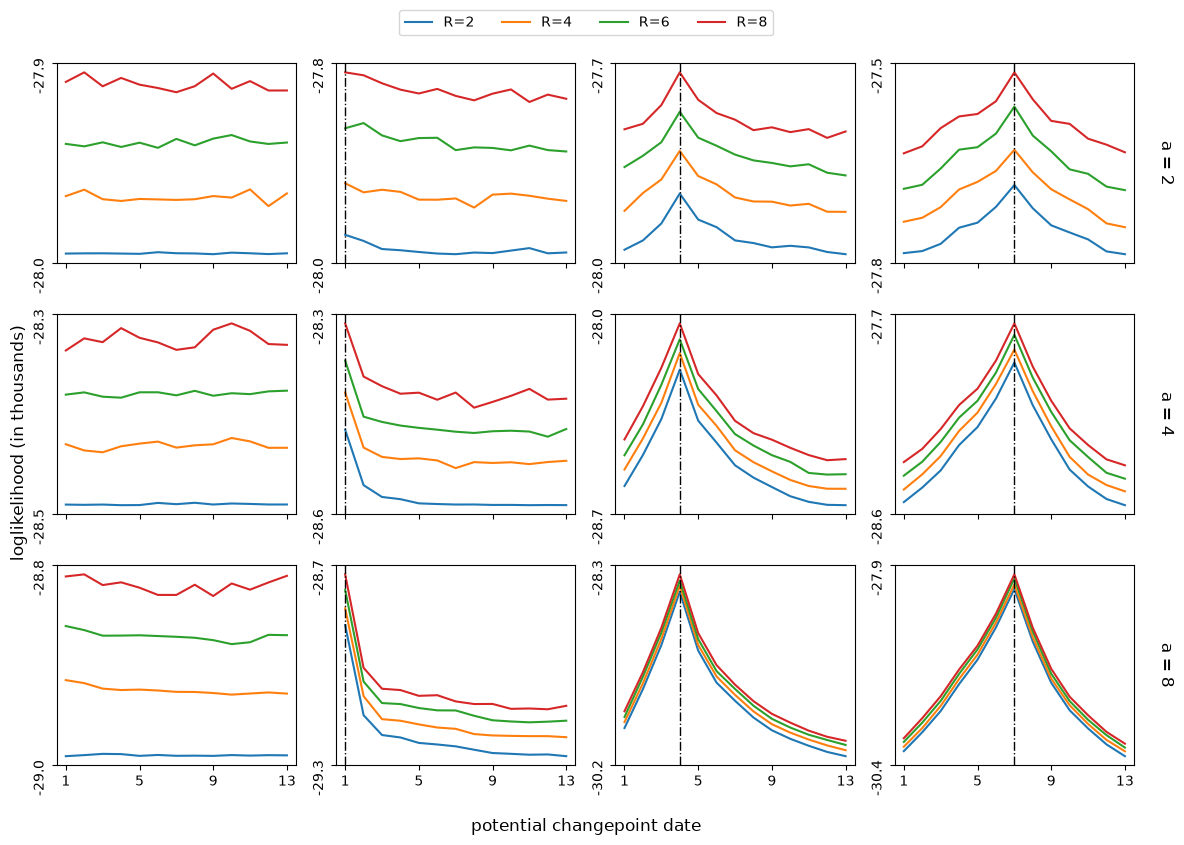

In [7]:
fig, axs = plt.subplots(
    nrows=len(magnitudes),
    ncols=len(changepoints),
    sharex=True,
    figsize=(4*len(magnitudes), 2*len(changepoints)),
    tight_layout=True
)

for row_idx, mag in enumerate(magnitudes):
    for col_idx, chpt in enumerate(changepoints):
        ax = axs[row_idx, col_idx]

        filename = f"ptotr_change_point_data_{chpt}changepoint_{mag}magnitude.tns"
        with open("results/H1_" + filename + '.pkl', 'rb') as f:
            fits = pickle.load(f)

        # plot loglikelihood values at fitted models
        l = ax.plot(fits[(mag, chpt)]/1000)
        # add vertical line at true tau value
        ax.axvline(x=chpt-1, color='black', linestyle='-.', linewidth=1)

        # format y-axis tick labels
        ymin, ymax = ax.get_ylim()
        y_ticks = [ymin, ymax]
        y_labels = [f"{tick:3.1f}" for tick in y_ticks]
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels, rotation=90)

    # add magnitude change values as text to the right of each row
    right_ax = ax
    right_ax.text(
        1.1,
        0.5,
        f"a = {mag}",
        transform=right_ax.transAxes,
        rotation=-90,
        va="center",
        ha="left",
        fontsize=12,
    )

# set x-axis ticks
axs[0,0].set_xlim(-0.5, 12.5)
plt.xticks(ticks=[0, 4, 8, 12], labels=[1,5,9,13])


fig.supxlabel('potential changepoint date')
fig.supylabel('loglikelihood (in thousands)')
fig.legend(handles=l, labels=[f"R={r}" for r in ranks],
           loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)
# Display the plot
plt.show()